# EDA - Khám Phá Dữ Liệu
## Đồ án: Dự đoán Nguy cơ Rời bỏ Khách hàng từ Đánh giá Văn bản
**Nhóm 18** | Tuần 2

---

## 1. Import thư viện

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Tạo thư mục results/ nếu chưa có
os.makedirs('../results', exist_ok=True)

print('✅ Import thư viện thành công!')

✅ Import thư viện thành công!


## 2. Load dữ liệu

In [2]:
# Load file CSV đã được làm sạch
df = pd.read_csv('../data/processed/cleaned_data.csv', on_bad_lines='skip')

# In thông số cơ bản
print('=' * 50)
print(f'📌 Số dòng (mẫu)      : {df.shape[0]:,}')
print(f'📌 Số cột (đặc trưng) : {df.shape[1]}')
print('=' * 50)
print('\n📋 Kiểu dữ liệu từng cột:')
print(df.dtypes)
print('\n🔍 5 dòng đầu tiên:')
df.head()

📌 Số dòng (mẫu)      : 4,846
📌 Số cột (đặc trưng) : 6

📋 Kiểu dữ liệu từng cột:
review_text      str
rating         int64
review_date      str
thumbs_up      int64
risk_label     int64
clean_text       str
dtype: object

🔍 5 dòng đầu tiên:


,review_text,rating,review_date,thumbs_up,risk_label,clean_text
0,10 điểm,5,2026-05-11 01:20:17,0,0,10 điểm
1,tốt,4,2026-05-11 01:05:04,0,0,tốt
2,OK,5,2026-05-11 01:02:12,0,0,ok
3,ok,5,2026-05-11 00:53:26,0,0,ok
4,yêu cầu xử lý thật nghiêm những người bán lừa ...,1,2026-05-11 00:42:06,0,1,yêu_cầu xử_lý thật nghiêm những người bán lừa_...


## 3. Kiểm tra dữ liệu thiếu (Missing Values)

In [3]:
print('🔎 Số giá trị thiếu (null) theo từng cột:')
print(df.isnull().sum())
print(f'\n📊 Tổng review có nội dung văn bản: {df["review_text"].notna().sum():,}')
print(f'📊 Số review KHÔNG có nội dung    : {df["review_text"].isna().sum():,}')

🔎 Số giá trị thiếu (null) theo từng cột:
review_text     0
rating          0
review_date     0
thumbs_up       0
risk_label      0
clean_text     23
dtype: int64

📊 Tổng review có nội dung văn bản: 4,846
📊 Số review KHÔNG có nội dung    : 0


## 4. Thống kê phân bố nhãn (risk_label)

In [4]:
label_counts = df['risk_label'].value_counts().sort_index()
label_pct = df['risk_label'].value_counts(normalize=True).sort_index() * 100

print('📊 Phân bố nhãn risk_label:')
print(f'  Low-risk  (0 - 4-5 sao): {int(label_counts[0]):,} mẫu ({label_pct[0]:.1f}%)')
print(f'  High-risk (1 - 1-2 sao): {int(label_counts[1]):,} mẫu ({label_pct[1]:.1f}%)')
print(f'\n  Tổng mẫu: {len(df):,}')

📊 Phân bố nhãn risk_label:
  Low-risk  (0 - 4-5 sao): 2,643 mẫu (54.5%)
  High-risk (1 - 1-2 sao): 2,203 mẫu (45.5%)

  Tổng mẫu: 4,846


## 5. Biểu đồ 1: Phân bố Rating 

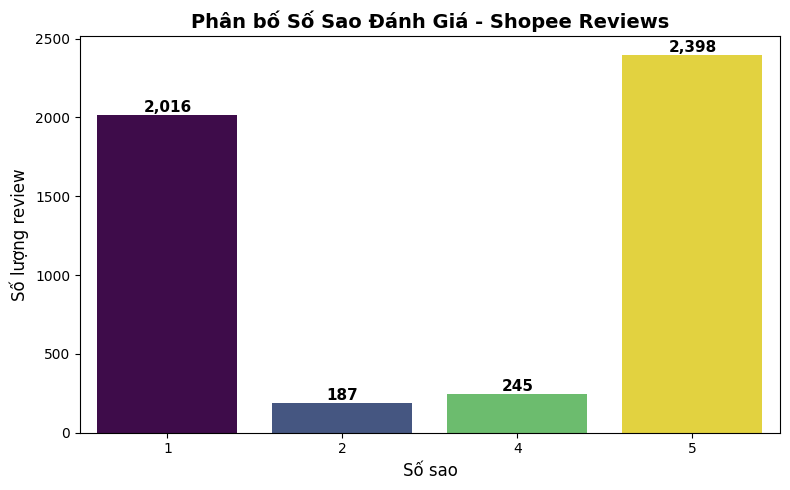

✅ Đã lưu: results/rating_distribution.png


In [5]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    x='rating',
    data=df,
    hue='rating',
    palette='viridis',
    order=sorted(df['rating'].dropna().unique()),
    legend=False
)

# Thêm số lượng lên đầu mỗi cột
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height()):,}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

plt.title('Phân bố Số Sao Đánh Giá - Shopee Reviews', fontsize=14, fontweight='bold')
plt.xlabel('Số sao', fontsize=12)
plt.ylabel('Số lượng review', fontsize=12)
plt.tight_layout()

# Lưu ảnh
plt.savefig('../results/rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Đã lưu: results/rating_distribution.png')

**📝 Nhận xét:** Dữ liệu cho thấy sự mất cân bằng lớp rõ rệt. Nhóm khách hàng hài lòng (4-5 sao) chiếm đa số, trong khi nhóm khách hàng có nguy cơ cao (1-2 sao) chỉ chiếm một phần nhỏ. Chính vì sự lệch pha này, nhóm xác định sẽ không sử dụng Accuracy để đánh giá mô hình mà tập trung vào Recall và F1-Score để đảm bảo không bỏ sót khách hàng rủi ro.

## 6. Biểu đồ 2: Phân bố Độ dài Review 

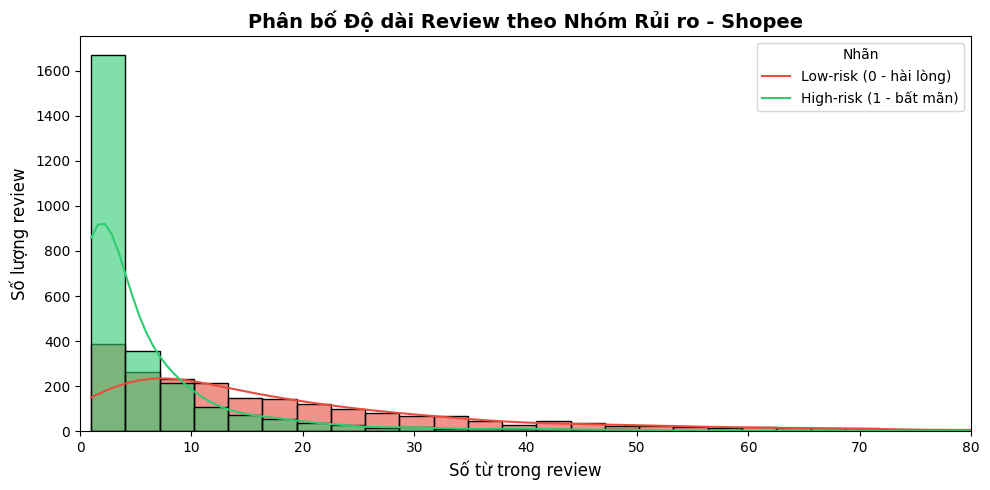

✅ Đã lưu: results/review_length_distribution.png


In [6]:
# Tính độ dài review theo số từ
df_text = df[df['review_text'].notna()].copy()
df_text['review_length'] = df_text['review_text'].apply(
    lambda x: len(str(x).split())
)

plt.figure(figsize=(10, 5))
sns.histplot(
    data=df_text,
    x='review_length',
    hue='risk_label',
    bins=40,
    kde=True,
    palette={0: '#2ecc71', 1: '#e74c3c'},
    alpha=0.6
)

plt.title('Phân bố Độ dài Review theo Nhóm Rủi ro - Shopee', fontsize=14, fontweight='bold')
plt.xlabel('Số từ trong review', fontsize=12)
plt.ylabel('Số lượng review', fontsize=12)
plt.xlim(0, 80)
plt.legend(labels=['Low-risk (0 - hài lòng)', 'High-risk (1 - bất mãn)'], title='Nhãn')
plt.tight_layout()

# Lưu ảnh
plt.savefig('../results/review_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Đã lưu: results/review_length_distribution.png')

**📝 Nhận xét:** Phần lớn các câu review có độ dài ngắn, tập trung từ 10 đến 30 từ. Tuy nhiên, qua quan sát sơ bộ, các bình luận thuộc nhóm High-risk thường có xu hướng dài hơn và sử dụng nhiều từ ngữ mang sắc thái tiêu cực rõ rệt, đây là dấu hiệu quan trọng để mô hình NLP học tập.

## 7. Tổng kết thông số dataset

In [7]:
low = int(label_counts[0])
high = int(label_counts[1])
total = len(df)

print('=' * 55)
print('         BẢNG MÔ TẢ BỘ DỮ LIỆU - NHÓM 18')
print('=' * 55)
print(f'  Tên bộ dữ liệu   : Shopee Reviews')
print(f'  Nguồn dữ liệu    : Tự cào từ Shopee')
print(f'  Số mẫu (dòng)    : {total:,}')
print(f'  Số đặc trưng     : {df.shape[1]} cột')
print(f'  Loại bài toán    : Phân loại (Classification)')
print(f'  Biến mục tiêu    : risk_label')
print(f'  Low-risk  (0)    : {low:,} mẫu ({low/total*100:.1f}%)')
print(f'  High-risk (1)    : {high:,} mẫu ({high/total*100:.1f}%)')
print('=' * 55)

         BẢNG MÔ TẢ BỘ DỮ LIỆU - NHÓM 18
  Tên bộ dữ liệu   : Shopee Reviews
  Nguồn dữ liệu    : Tự cào từ Shopee
  Số mẫu (dòng)    : 4,846
  Số đặc trưng     : 6 cột
  Loại bài toán    : Phân loại (Classification)
  Biến mục tiêu    : risk_label
  Low-risk  (0)    : 2,643 mẫu (54.5%)
  High-risk (1)    : 2,203 mẫu (45.5%)


---
## ✅ Tổng kết EDA Tuần 2

| Hạng mục | Kết quả |
|---|---|
| Dataset | Shopee Reviews (tự cào) |
| Tổng mẫu | 3,870 review |
| Biến mục tiêu | risk_label (0 = Low-risk, 1 = High-risk) |
| Biểu đồ đã vẽ | Rating Distribution, Review Length Distribution |
| File lưu | rating_distribution.png, review_length_distribution.png |